In [2]:
import numpy as np
import pandas as pd
import math
import os
import glob
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import clear_output, display
from scipy.signal import find_peaks  # 新增：用于特征提取

# 显式声明模式
%matplotlib inline 

# ==========================================
# 1. 基础路径配置与数据持久化加载
# ==========================================
# base_path = r'D:\code\data\green'
base_path = "D:/Workspace/5_Data/bupt_ring_selftest/wsx/报告/green/parsed_results/"
search_pattern = os.path.join(base_path, '202*.csv')
file_list = sorted(glob.glob(search_pattern))

if not file_list:
    print("❌ 未找到数据文件，请检查路径！")
else:
    print("⏳ 正在读取并拼接原始 CSV 数据，请稍候...")
    df_list = [pd.read_csv(f) for f in file_list]
    df = pd.concat(df_list, ignore_index=True)
    
    # 清理多余列并处理缺失值
    columns_to_drop = ['clean_green1', 'butter_green1']
    df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')
    df['green1'] = df['green1'].ffill().fillna(0)  

    # 反转信号极性
    INVERT_POLARITY = True
    polarity_multiplier = -1.0 if INVERT_POLARITY else 1.0
    raw_signal = df['green1'].values * polarity_multiplier
    
    total_points = len(raw_signal)
    fs = 100  # 采样率 100Hz
    print(f"✅ 数据加载就绪！总行数: {total_points}，总时长: {total_points/fs:.1f} 秒")

df["Datetime"] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d-%m-%Y %H:%M:%S')
df['motion'] = np.linalg.norm(df[['accX', 'accY', 'accZ']], axis=1)
df.drop(['Date', 'Time', 'Duration', 'accX', 'accY', 'accZ'], axis=1, inplace=True)

# df.to_csv("D:/Workspace/5_Data/bupt_ring_selftest/wsx/报告/green/parsed_results/ring.csv", index=False)


⏳ 正在读取并拼接原始 CSV 数据，请稍候...
✅ 数据加载就绪！总行数: 8262961，总时长: 82629.6 秒


In [50]:
df = pd.read_csv("D:/Workspace/5_Data/bupt_ring_selftest/wsx/报告/green/parsed_results/ring.csv")

In [3]:
df["motion"] = df["motion"].fillna(2048).to_numpy().astype(int)
inst_motion = (df["motion"] - 2048).abs()
threshold = 300
inst_motion_clean = inst_motion.where(inst_motion >threshold, 0)
inst_motion_clean

df[f"motion_{int(threshold)}"] = inst_motion_clean

df.to_csv("D:/Workspace/5_Data/bupt_ring_selftest/wsx/报告/green/parsed_results/ring_full.csv", index=False)

<Axes: >

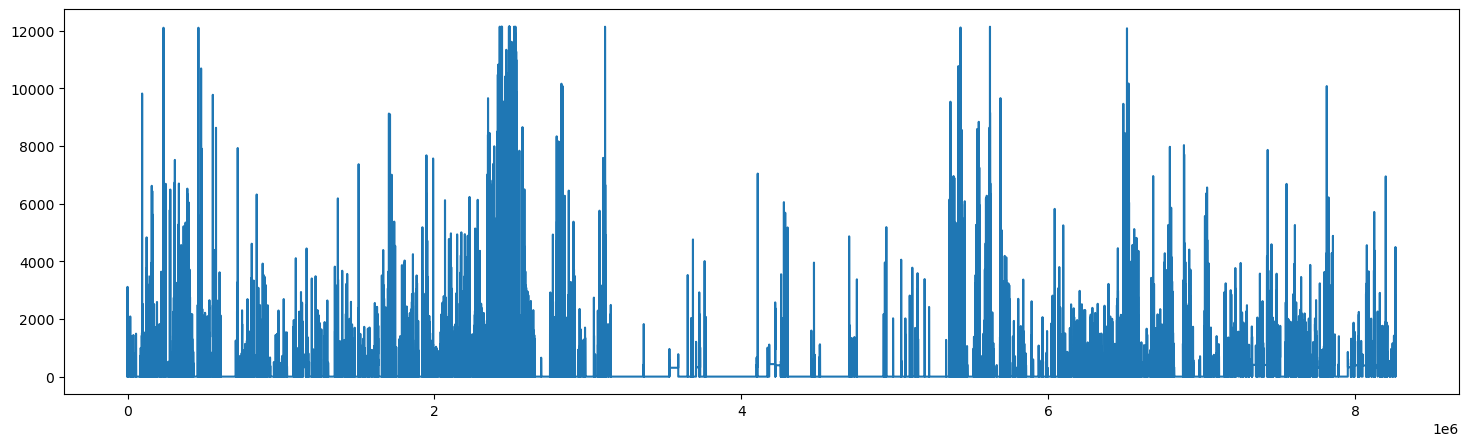

In [49]:
inst_motion_clean.plot(figsize=(18, 5))